In [36]:
import pathlib
import re
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [4]:
SIM_ROOT = pathlib.Path("../")
sims = sorted(SIM_ROOT.glob("sim_*"))
sims

[PosixPath('../sim_2017-01-01'),
 PosixPath('../sim_2017-01-21'),
 PosixPath('../sim_2017-02-10'),
 PosixPath('../sim_2017-04-11'),
 PosixPath('../sim_2017-07-20'),
 PosixPath('../sim_2017-10-28'),
 PosixPath('../sim_2018-01-06'),
 PosixPath('../sim_2018-01-26'),
 PosixPath('../sim_2018-02-15'),
 PosixPath('../sim_2019-01-11'),
 PosixPath('../sim_2019-01-31'),
 PosixPath('../sim_2019-02-20'),
 PosixPath('../sim_2019-05-31'),
 PosixPath('../sim_2019-09-08'),
 PosixPath('../sim_2019-12-17'),
 PosixPath('../sim_2020-01-16'),
 PosixPath('../sim_2020-02-05')]

In [17]:
re_dt = re.compile(r"(\d+\.\d+) elapsed seconds")

In [26]:
def get_rsl_dt(f):
    rsl = f.read_text().splitlines()
    rsl = [l for l in rsl if "Timing for main" in l]
    rsl_dt = re_dt.findall("".join(rsl))
    rsl_dt = [float(t) for t in rsl_dt]
    return rsl_dt

In [30]:
dt_df = {s.name: get_rsl_dt(s / "3_wrf/rsl.out.0000") for s in sims}

# Pad with NaNs to make series of equal length
max_len = max(len(v) for v in dt_df.values())
dt_df = {k: v + [float("nan")] * (max_len - len(v)) for k, v in dt_df.items()}
dt_df = pd.DataFrame(dt_df)
dt_df

,sim_2017-01-01,sim_2017-01-21,sim_2017-02-10,sim_2017-04-11,sim_2017-07-20,sim_2017-10-28,sim_2018-01-06,sim_2018-01-26,sim_2018-02-15,sim_2019-01-11,sim_2019-01-31,sim_2019-02-20,sim_2019-05-31,sim_2019-09-08,sim_2019-12-17,sim_2020-01-16,sim_2020-02-05
0,15.39703,17.05713,17.23718,23.43154,25.06830,22.19680,17.14985,17.96011,17.74149,17.09504,16.97181,23.45870,25.08365,23.44310,23.76093,17.99790,17.57545
1,0.74388,0.92729,0.95153,3.81784,3.56304,2.47945,0.97888,1.30426,1.65942,0.99494,0.99483,3.85349,3.92704,3.86210,3.79713,1.98103,1.36388
2,0.72301,0.91665,0.94173,3.79004,3.53799,3.51063,0.96247,1.68175,1.83543,0.97971,0.97992,3.82315,3.96484,3.71344,3.84475,1.89943,1.75124
3,0.72995,0.90776,0.93484,3.82638,3.50330,3.79695,0.95957,1.77239,1.76203,0.97504,0.98078,3.85907,3.92661,3.83323,3.76149,1.92402,1.77163
4,0.72338,0.91068,0.92894,3.81852,3.50869,3.81732,0.94808,1.81670,1.72346,0.96971,0.98250,3.89744,3.90022,3.86367,3.71131,1.90388,1.80610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47515,NaN,NaN,NaN,NaN,NaN,NaN,0.97724,NaN,NaN,0.90042,0.79718,NaN,NaN,NaN,NaN,NaN,NaN
47516,NaN,NaN,NaN,NaN,NaN,NaN,0.97079,NaN,NaN,0.87350,0.79727,NaN,NaN,NaN,NaN,NaN,NaN
47517,NaN,NaN,NaN,NaN,NaN,NaN,0.96386,NaN,NaN,0.91180,0.79927,NaN,NaN,NaN,NaN,NaN,NaN
47518,NaN,NaN,NaN,NaN,NaN,NaN,0.96090,NaN,NaN,0.89371,0.79887,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

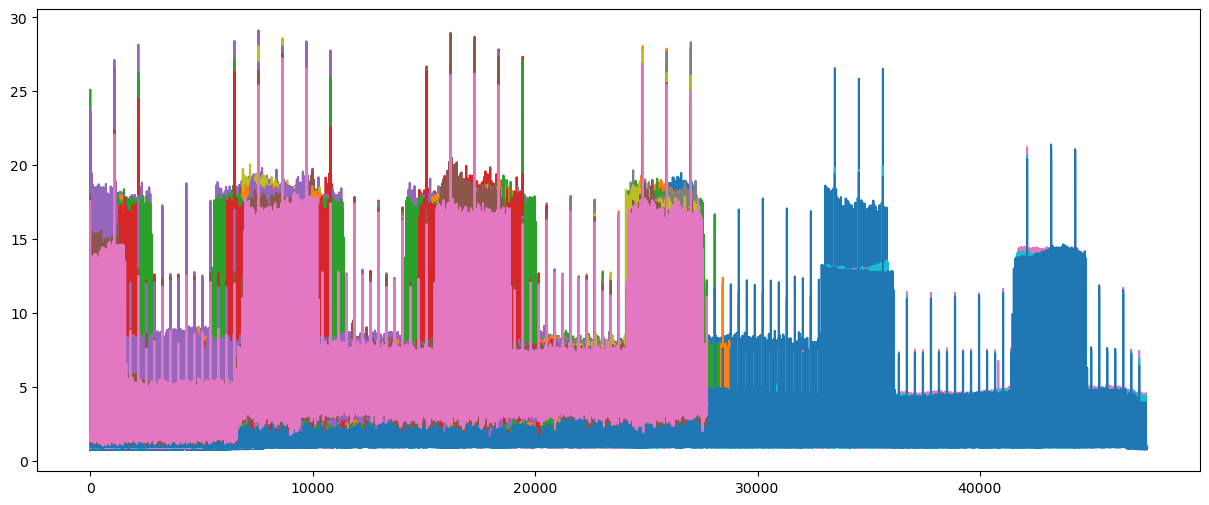

In [32]:
fig, ax = plt.subplots(figsize=(15, 6))
dt_df.plot(ax=ax, legend=False)

<Axes: ylabel='Frequency'>

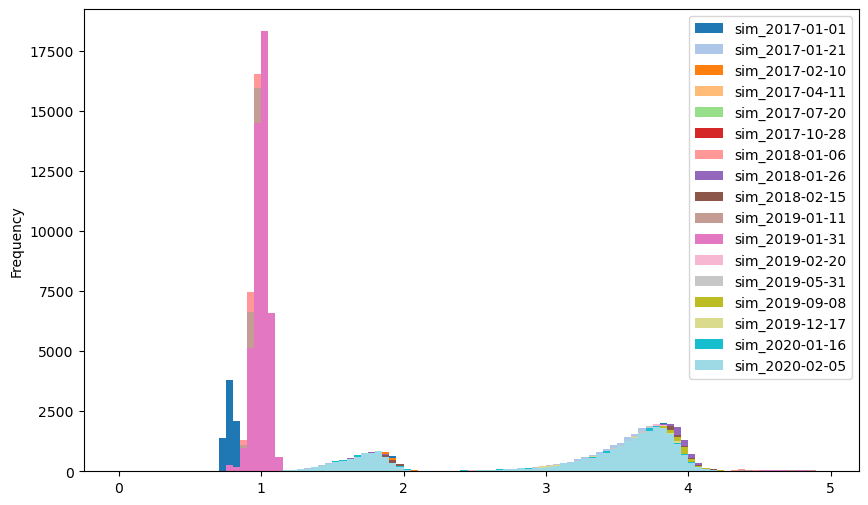

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
dt_df.plot.hist(bins=np.arange(0, 5, .05), ax=ax, cmap="tab20")